In [1]:
#import necessary libraries
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from matplotlib.ticker import AutoMinorLocator

import xarray as xr
import scipy

from scipy import stats
from scipy.stats import pearsonr, linregress

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

import time
from datetime import datetime, date

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.ticker import MaxNLocator, FuncFormatter
import matplotlib.dates as mdates


import shapefile
from mpl_toolkits.axes_grid1 import make_axes_locatable
import warnings
import os

import sys
import os.path
import subprocess
import math
import csv

from netCDF4 import Dataset

#import s3fs
import copy
import json, copy
from pandas import DataFrame
from osgeo import gdal, ogr, osr

import warnings
warnings.filterwarnings("ignore")

In [2]:
dataset = xr.open_dataset(r'D:\MSRSGI\Masters_thesis\Data\Vertical_deformation_data\VuGlobal.grd')
print(dataset)

<xarray.Dataset> Size: 4MB
Dimensions:  (x: 1441, y: 721)
Coordinates:
  * x        (x) float64 12kB 0.0 0.25 0.5 0.75 1.0 ... 359.2 359.5 359.8 360.0
  * y        (y) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.25 89.5 89.75 90.0
Data variables:
    z        (y, x) float32 4MB ...
Attributes:
    Conventions:  CF-1.7
    title:        
    history:      gmt xyz2grd /home/bill/Science/XYZfiles14/vlm/GPSImaging/te...
    description:  
    GMT_version:  6.4.0 [64-bit]


In [3]:
dataset.z.values

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(721, 1441), dtype=float32)

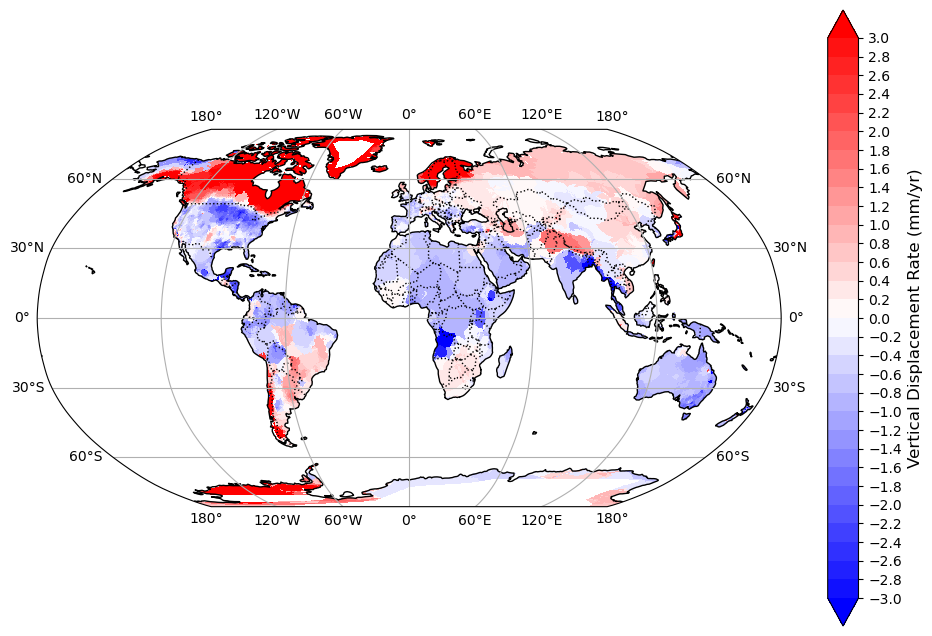

In [4]:
from matplotlib.colors import BoundaryNorm

# Assuming 'ds' is your xarray.Dataset loaded already, and contains variable 'z'
# Extract variable z and its coordinates
z = dataset['z']
x = dataset['x'].values  # longitude or x coordinates
y = dataset['y'].values  # latitude or y coordinates

# Define explicit colorbar values (levels)
color_levels = [-3, -2.8, -2.6, -2.4, -2.2, -2, -1.8, -1.6, -1.4, -1.2, -1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3]  # Customize to your data range
cmap = plt.get_cmap('bwr')        # Choose colormap ---bwr
norm = BoundaryNorm(color_levels, ncolors=cmap.N, extend='both')

x2d, y2d = np.meshgrid(x, y)

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.Robinson()})

# Use norm in pcolormesh so colors match specified levels
im = ax.pcolormesh(x2d, y2d, z.values, cmap=cmap, norm=norm,
                   shading='auto', transform=ccrs.PlateCarree())

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.gridlines(draw_labels=True)

# Pass your explicit ticks to colorbar
cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.05,
                    ticks=color_levels, extend='both')

cbar.set_label('Vertical Displacement Rate (mm/yr)', fontsize=12)

#ax.set_title('Map of variable z with explicit colorbar levels', fontsize=16)

plt.show()

In [5]:
dataset_renamed = dataset.rename({'x': 'lon', 'y': 'lat', 'z': 'VLM_Rate'})
dataset_renamed 

<xarray.Dataset> Size: 4MB
Dimensions:   (lon: 1441, lat: 721)
Coordinates:
  * lon       (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8 360.0
  * lat       (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
Data variables:
    VLM_Rate  (lat, lon) float32 4MB nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    Conventions:  CF-1.7
    title:        
    history:      gmt xyz2grd /home/bill/Science/XYZfiles14/vlm/GPSImaging/te...
    description:  
    GMT_version:  6.4.0 [64-bit]

In [7]:
# # Convert to xarray Dataset with longitude and latitude as coords
# vlm = df.set_index(['lon', 'lat']).to_xarray();

# Assign attributes to longitude coordinate
dataset_renamed['lon'].attrs['units'] = 'degrees_east'
dataset_renamed['lon'].attrs['long_name'] = 'longitude'
dataset_renamed['lon'].attrs['standard_name'] = 'longitude'
dataset_renamed['lon'].attrs['axis'] = 'X'
dataset_renamed['lon'].attrs['comment'] = 'longitude value at each pixel'

# Assign attributes to latitude coordinate
dataset_renamed['lat'].attrs['units'] = 'degrees_north'
dataset_renamed['lat'].attrs['long_name'] = 'latitude'
dataset_renamed['lat'].attrs['standard_name'] = 'latitude'
dataset_renamed['lat'].attrs['axis'] = 'Y'
dataset_renamed['lat'].attrs['comment'] = 'latitude value at each pixel'


# Assuming vlm is your loaded Dataset
dataset_renamed['VLM_Rate'].attrs.update({
    'units': 'mm/yr',
    'long_name': 'Interpolated Vertical Rate'
})

dataset_renamed.attrs.update({
    'title': 'Interpolated Global Vertical Land Rate Models',
    'source': 'Nevada Geodetic Laboratory (https://geodesy.unr.edu/vlm/VLM_Global_Imaged.txt)',
    'Contact': 'Sudur Bhattarai (uhkmj@kit.edu)'
})

dataset_renamed

<xarray.Dataset> Size: 4MB
Dimensions:   (lon: 1441, lat: 721)
Coordinates:
  * lon       (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8 360.0
  * lat       (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
Data variables:
    VLM_Rate  (lat, lon) float32 4MB nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    Conventions:  CF-1.7
    title:        Interpolated Global Vertical Land Rate Models
    history:      gmt xyz2grd /home/bill/Science/XYZfiles14/vlm/GPSImaging/te...
    description:  
    GMT_version:  6.4.0 [64-bit]
    source:       Nevada Geodetic Laboratory (https://geodesy.unr.edu/vlm/VLM...
    Contact:      Sudur Bhattarai (uhkmj@kit.edu)

In [8]:
dataset_renamed.to_netcdf(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Processed Data/VLM_Rate.nc')

In [6]:
VLM_Rate = xr.open_dataset(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Processed Data/VLM_Rate.nc')
VLM_Rate

<xarray.Dataset> Size: 4MB
Dimensions:   (lon: 1441, lat: 721)
Coordinates:
  * lon       (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8 360.0
  * lat       (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
Data variables:
    VLM_Rate  (lat, lon) float32 4MB ...
Attributes:
    Conventions:  CF-1.7
    title:        Interpolated Global Vertical Land Rate Models
    history:      gmt xyz2grd /home/bill/Science/XYZfiles14/vlm/GPSImaging/te...
    description:  
    GMT_version:  6.4.0 [64-bit]
    source:       Nevada Geodetic Laboratory (https://geodesy.unr.edu/vlm/VLM...
    Contact:      Sudur Bhattarai (uhkmj@kit.edu)

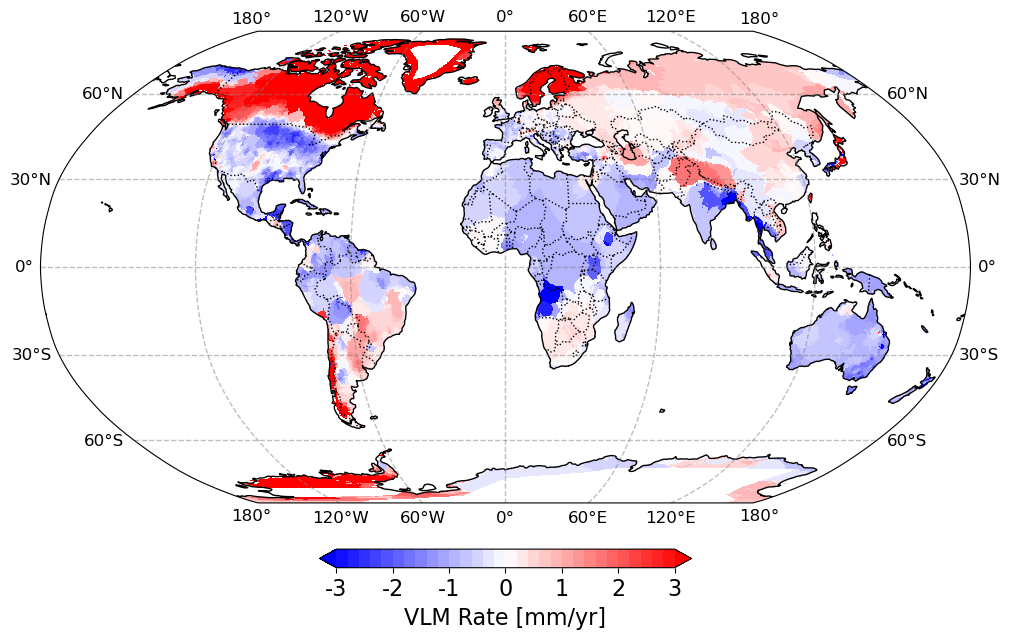

In [10]:
from matplotlib.colors import BoundaryNorm

# Assuming 'ds' is your xarray.Dataset loaded already, and contains variable 'z'
# Extract variable z and its coordinates
vlm = VLM_Rate['VLM_Rate']
lon = VLM_Rate['lon'].values  # longitude or x coordinates
lat = VLM_Rate['lat'].values  # latitude or y coordinates

# Define explicit colorbar values (levels)
color_levels = [-3, -2.8, -2.6, -2.4, -2.2, -2, -1.8, -1.6, -1.4, -1.2, -1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3]  # Customize to your data range
cmap = plt.get_cmap('bwr')        # Choose colormap ---bwr
norm = BoundaryNorm(color_levels, ncolors=cmap.N, extend='both')

x2d, y2d = np.meshgrid(lon, lat)

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.Robinson()})

# Use norm in pcolormesh so colors match specified levels
im = ax.pcolormesh(x2d, y2d, vlm.values, cmap=cmap, norm=norm,
                   shading='auto', transform=ccrs.PlateCarree())

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
# ax.gridlines(draw_labels=True)


gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')

# Hide unwanted labels if you want
gl.top_labels = True

# Adjust font size for longitude (x-axis) grid labels
gl.xlabel_style = {'size': 12}  # 14 is the font size in points

# Adjust font size for latitude (y-axis) grid labels
gl.ylabel_style = {'size': 12}  # similarly 14pt font size for y labels


# Define major ticks at whole numbers only
major_ticks = np.arange(-3, 4, 1)  # -3, -2, -1, 0, 1, 2, 3

# # Create the colorbar with major ticks being whole numbers
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.075, extend='both', shrink=0.4)

# Set major ticks at whole numbers
cbar.set_ticks(major_ticks)

# Format major tick labels as integers
cbar.ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

# Turn on minor ticks
cbar.ax.minorticks_on()

# Define minor ticks to be all color_levels except major ticks
minor_ticks = sorted(set(color_levels) - set(major_ticks))

# Normalize minor tick positions to colorbar axis scale and set them
# But colorbar axis ticks expect normalized positions, so use the same normalization used in colorbar:
minor_tick_locs = norm(minor_ticks)
cbar.ax.xaxis.set_minor_locator(ticker.FixedLocator(minor_tick_locs))

# Hide minor tick labels (leave ticks visible but no labels)
cbar.ax.xaxis.set_minor_formatter(ticker.NullFormatter())

cbar.ax.tick_params(labelsize=16)  # Change 12 to your desired font size


cbar.set_label('VLM Rate [mm/yr]', fontsize=16)

plt.savefig(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Processed Data/Global_VLM_Rate_new_ones.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
VLM_Rate = xr.open_dataset(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Processed Data/VLM_Rate.nc')
VLM_Rate

<xarray.Dataset> Size: 4MB
Dimensions:   (lon: 1441, lat: 721)
Coordinates:
  * lon       (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8 360.0
  * lat       (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
Data variables:
    VLM_Rate  (lat, lon) float32 4MB ...
Attributes:
    Conventions:  CF-1.7
    title:        Interpolated Global Vertical Land Rate Models
    history:      gmt xyz2grd /home/bill/Science/XYZfiles14/vlm/GPSImaging/te...
    description:  
    GMT_version:  6.4.0 [64-bit]
    source:       Nevada Geodetic Laboratory (https://geodesy.unr.edu/vlm/VLM...
    Contact:      Sudur Bhattarai (uhkmj@kit.edu)

In [16]:
non_nan_count = VLM_Rate['VLM_Rate'].count().item()
print(non_nan_count)

274333


In [ ]:
# Plot results
TIME = "2005-04"
plot_kwargs = dict(vmin=-400, coastlines=True, gridlines=True)

fig, axs = plt.subplots(
    ncols=2, figsize=(8, 3), subplot_kw={"projection": ccrs.EqualEarth()}
)


fig.suptitle(f"TWS Anomaly, {TIME}", weight="bold")
slr.twsa_slr_2024.sel(time=TIME).dr.projplot(ax=axs[0], **plot_kwargs)
csr_grid.sel(time=TIME).dr.projplot(ax=axs[1], **plot_kwargs)

# axs[0].set_title("IGG-SLR-DORIS")
# axs[1].set_title("CSR GRACE, w/ land mask");

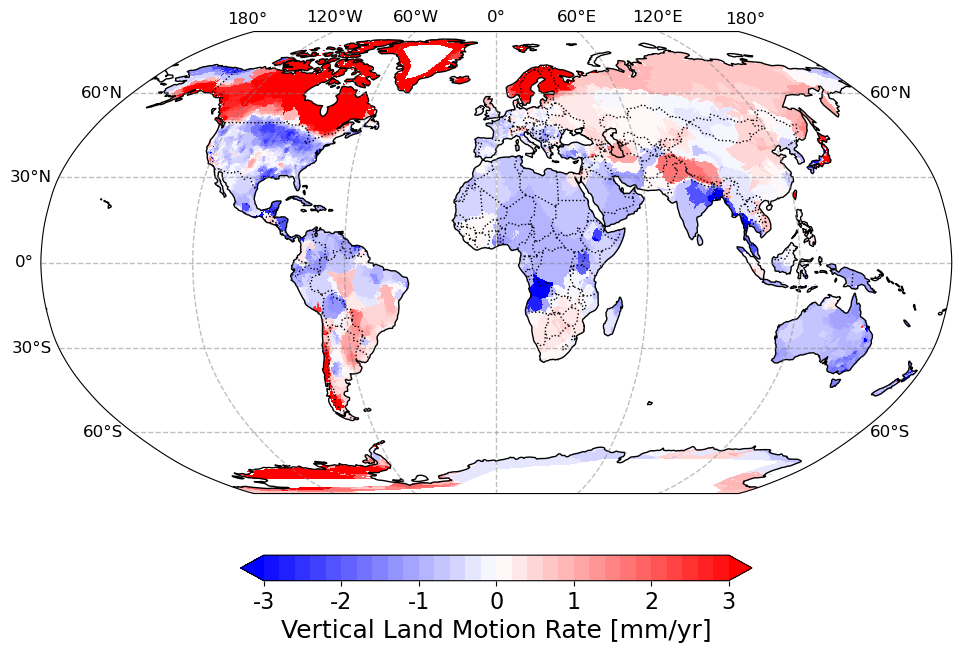

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm

# Assume VLM_Rate is your xarray.Dataset already loaded with dims lat, lon
# with variable 'VLM_Rate' inside it.

vlm = VLM_Rate['VLM_Rate']  # xarray.DataArray (lat, lon)
lat = VLM_Rate['lat'].values
lon = VLM_Rate['lon'].values

# Convert longitude from [0,360] to [-180,180]
lon_adjusted = ((lon + 180) % 360) - 180

# Sort the adjusted longitude and the VLM data accordingly
sort_idx = np.argsort(lon_adjusted)
lon_sorted = lon_adjusted[sort_idx]
vlm_sorted = vlm.values[:, sort_idx]

# Create meshgrid with sorted longitude and original latitude
x2d, y2d = np.meshgrid(lon_sorted, lat)

# Define color levels (customize as needed)
color_levels = [-3, -2.8, -2.6, -2.4, -2.2, -2, -1.8, -1.6, -1.4, -1.2,
                -1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8,
                1, 1.2, 1.4, 1.6, 1.8, 2, 2.2, 2.4, 2.6, 2.8, 3]
cmap = plt.get_cmap('bwr')  # blue-white-red centered colormap
norm = BoundaryNorm(color_levels, ncolors=cmap.N, extend='both')

# Create the figure and axis with the Robinson projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.Robinson()})

# Plot using pcolormesh and PlateCarree transformation
im = ax.pcolormesh(x2d, y2d, vlm_sorted, cmap=cmap, norm=norm, shading='auto',
                   transform=ccrs.PlateCarree())

# Add coastlines and borders
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Add gridlines with labels
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = True
gl.left_labels = True
gl.right_labels = False
gl.bottom_labels = False
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}

# Define major ticks for the colorbar
major_ticks = np.arange(-3, 4, 1)

# Create colorbar below the plot
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.1,
                    extend='both', shrink=0.55)
cbar.set_ticks(major_ticks)
cbar.ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
cbar.ax.minorticks_on()
minor_ticks = sorted(set(color_levels) - set(major_ticks))
minor_tick_locs = norm(minor_ticks)
cbar.ax.xaxis.set_minor_locator(ticker.FixedLocator(minor_tick_locs))
cbar.ax.xaxis.set_minor_formatter(ticker.NullFormatter())
cbar.ax.tick_params(labelsize=16)
cbar.set_label('Vertical Land Motion Rate [mm/yr]', fontsize=18)

#plt.savefig('VLM_Rate_Global_Map_corrected.png', dpi=300, bbox_inches='tight')
plt.show()

## FOR UNCERTAINTY 15th NOV

In [25]:
vlm = xr.open_dataset(r'VLM_Global_Imaged.nc')
vlm

<xarray.Dataset> Size: 42MB
Dimensions:  (Lon: 1441, Lat: 721)
Dimensions without coordinates: Lon, Lat
Data variables:
    LonGrid  (Lon, Lat) float64 8MB ...
    LatGrid  (Lon, Lat) float64 8MB ...
    VU       (Lon, Lat) float64 8MB ...
    SVU      (Lon, Lat) float64 8MB ...
    ZETA     (Lon, Lat) float64 8MB ...
Attributes:
    Source:    NetCDF file created using Matlab by Bill Hammond on 12-Jul-2025.
    Citation:  Hammond, W.C., G. Blewitt, C. Kreemer, and R.S. Nerem, 2021, G...
    Units:     LonGrid,LatGrid are in degrees. VU, SVU and ZETA are in mm/yr....

In [27]:
uncertainty = vlm.SVU
uncertainty

<xarray.DataArray 'SVU' (Lon: 1441, Lat: 721)> Size: 8MB
[1038961 values with dtype=float64]
Dimensions without coordinates: Lon, Lat

In [29]:
uncertainty.to_netcdf(r'VLM_rate_uncertainty1.nc')

In [30]:
Uncertainty1 = xr.open_dataset(r'VLM_rate_uncertainty1.nc')
Uncertainty1

<xarray.Dataset> Size: 8MB
Dimensions:  (Lon: 1441, Lat: 721)
Dimensions without coordinates: Lon, Lat
Data variables:
    SVU      (Lon, Lat) float64 8MB ...

In [31]:
Uncertainty1.SVU.values

array([[0.34753615, 0.34798378, 0.34849956, ...,        nan,        nan,
               nan],
       [0.34753615, 0.34798673, 0.34850613, ...,        nan,        nan,
               nan],
       [0.34753615, 0.34798968, 0.34851268, ...,        nan,        nan,
               nan],
       ...,
       [0.34753615, 0.34797784, 0.34848635, ...,        nan,        nan,
               nan],
       [0.34753615, 0.34798081, 0.34849296, ...,        nan,        nan,
               nan],
       [0.34753615, 0.34798378, 0.34849956, ...,        nan,        nan,
               nan]], shape=(1441, 721))

In [32]:
Uncertainty1.SVU.Lon.values

array([   0,    1,    2, ..., 1438, 1439, 1440], shape=(1441,))

In [33]:
Uncertainty1.SVU.Lat.values

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [35]:
VLM_Rate = xr.open_dataset(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Processed Data/VLM_Rate.nc')
VLM_Rate

<xarray.Dataset> Size: 4MB
Dimensions:   (lon: 1441, lat: 721)
Coordinates:
  * lon       (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8 360.0
  * lat       (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
Data variables:
    VLM_Rate  (lat, lon) float32 4MB ...
Attributes:
    Conventions:  CF-1.7
    title:        Interpolated Global Vertical Land Rate Models
    history:      gmt xyz2grd /home/bill/Science/XYZfiles14/vlm/GPSImaging/te...
    description:  
    GMT_version:  6.4.0 [64-bit]
    source:       Nevada Geodetic Laboratory (https://geodesy.unr.edu/vlm/VLM...
    Contact:      Sudur Bhattarai (uhkmj@kit.edu)

In [18]:
# Rename coordinates to match
Uncertainty1 = Uncertainty1.rename({'Lon': 'lon', 'Lat': 'lat'})

# Assign new coordinate values matching VLM_Rate
Uncertainty1 = Uncertainty1.assign_coords({
    'lon': VLM_Rate.lon.values,
    'lat': VLM_Rate.lat.values
})
Uncertainty1

<xarray.Dataset> Size: 8MB
Dimensions:  (lon: 1441, lat: 721)
Coordinates:
  * lon      (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8 360.0
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
Data variables:
    SVU      (lon, lat) float64 8MB 0.3475 0.348 0.3485 0.349 ... nan nan nan

In [21]:
vlm = Uncertainty1['SVU'].transpose('lat', 'lon')
vlm

<xarray.DataArray 'SVU' (lat: 721, lon: 1441)> Size: 8MB
array([[0.34753615, 0.34753615, 0.34753615, ..., 0.34753615, 0.34753615,
        0.34753615],
       [0.34798378, 0.34798673, 0.34798968, ..., 0.34797784, 0.34798081,
        0.34798378],
       [0.34849956, 0.34850613, 0.34851268, ..., 0.34848635, 0.34849296,
        0.34849956],
       ...,
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]], shape=(721, 1441))
Coordinates:
  * lon      (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8 360.0
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import TwoSlopeNorm

# Select dataset variable
tws_hhu = vlm.transpose('lat', 'lon')

vmin = -1
vmax = 1
norm = TwoSlopeNorm(vmin=vmin, vmax=vmax, vcenter=0)  # keeps color centered on zero

fig, ax = plt.subplots(figsize=(15, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# MAIN CHANGE: Do NOT pass 'levels' to imshow (or pcolormesh)
im = tws_hhu.plot.imshow(
    ax=ax,
    norm=norm,
    cmap='bwr',  # continuous reversed jet colormap --- jet_r
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('Improved point mass solution - TWS Anomaly (April 2002)', fontsize=20, pad=15)

# Colorbar: by default matplotlib will give you a continuous colorbar
pos = ax.get_position()
cbar_left = pos.x0
cbar_width = pos.width * 1
cbar_bottom = pos.y0 - 0.08
cbar_height = 0.02

cbar_ax = fig.add_axes([cbar_left, cbar_bottom, cbar_width, cbar_height])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', shrink=0.9)
cbar.set_label('EWH [mm]', fontsize=16, labelpad=10)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.tick_params(labelsize=14)

# plt.savefig('IPM_COSTG_with_K_continuous.png')
plt.show()

ValueError: Dimensions {'lat', 'lon'} do not exist. Expected one or more of FrozenMappingWarningOnValuesAccess({'Lon': 1441, 'Lat': 721})

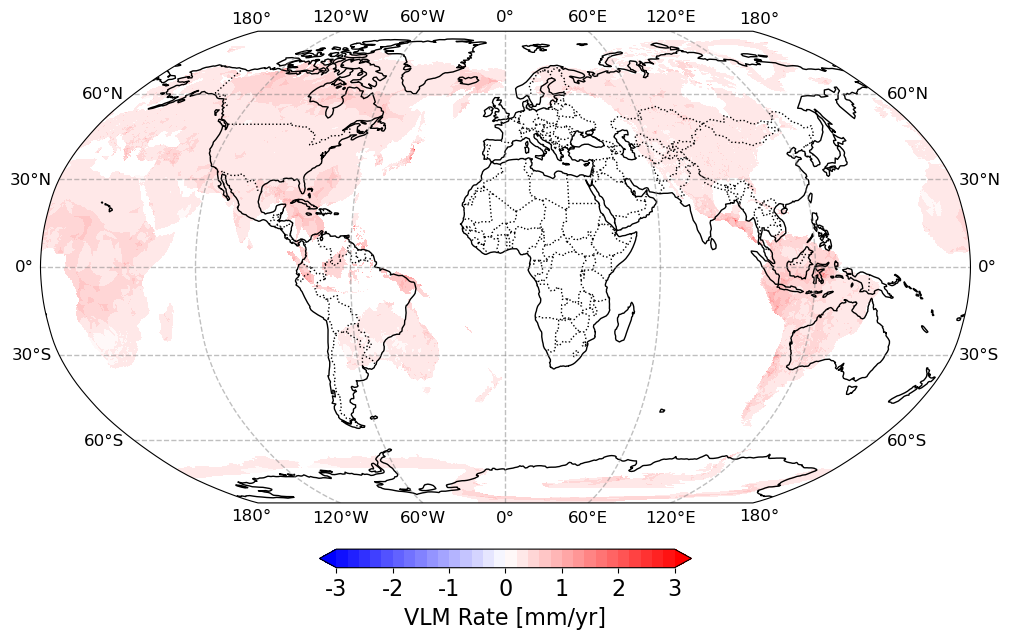

In [20]:
from matplotlib.colors import BoundaryNorm

# Assuming 'ds' is your xarray.Dataset loaded already, and contains variable 'z'
# Extract variable z and its coordinates
vlm = Uncertainty1['SVU'].transpose('lat', 'lon')
lon = Uncertainty1['lon'].values  # longitude or x coordinates
lat = Uncertainty1['lat'].values  # latitude or y coordinates

# Define explicit colorbar values (levels)
color_levels = [-3, -2.8, -2.6, -2.4, -2.2, -2, -1.8, -1.6, -1.4, -1.2, -1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3]  # Customize to your data range
cmap = plt.get_cmap('bwr')        # Choose colormap ---bwr
norm = BoundaryNorm(color_levels, ncolors=cmap.N, extend='both')

x2d, y2d = np.meshgrid(lon, lat)

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.Robinson()})

# Use norm in pcolormesh so colors match specified levels
im = ax.pcolormesh(x2d, y2d, vlm.values, cmap=cmap, norm=norm,
                   shading='auto', transform=ccrs.PlateCarree())

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
# ax.gridlines(draw_labels=True)


gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')

# Hide unwanted labels if you want
gl.top_labels = True

# Adjust font size for longitude (x-axis) grid labels
gl.xlabel_style = {'size': 12}  # 14 is the font size in points

# Adjust font size for latitude (y-axis) grid labels
gl.ylabel_style = {'size': 12}  # similarly 14pt font size for y labels


# Define major ticks at whole numbers only
major_ticks = np.arange(-3, 4, 1)  # -3, -2, -1, 0, 1, 2, 3

# # Create the colorbar with major ticks being whole numbers
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.075, extend='both', shrink=0.4)

# Set major ticks at whole numbers
cbar.set_ticks(major_ticks)

# Format major tick labels as integers
cbar.ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

# Turn on minor ticks
cbar.ax.minorticks_on()

# Define minor ticks to be all color_levels except major ticks
minor_ticks = sorted(set(color_levels) - set(major_ticks))

# Normalize minor tick positions to colorbar axis scale and set them
# But colorbar axis ticks expect normalized positions, so use the same normalization used in colorbar:
minor_tick_locs = norm(minor_ticks)
cbar.ax.xaxis.set_minor_locator(ticker.FixedLocator(minor_tick_locs))

# Hide minor tick labels (leave ticks visible but no labels)
cbar.ax.xaxis.set_minor_formatter(ticker.NullFormatter())

cbar.ax.tick_params(labelsize=16)  # Change 12 to your desired font size


cbar.set_label('VLM Rate [mm/yr]', fontsize=16)

#plt.savefig(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Processed Data/Global_VLM_Rate_new_ones.png', dpi=300, bbox_inches='tight')
plt.show()

------
-------

In [33]:
vlm = xr.open_dataset(r'VLM_Global_Imaged.nc')
vlm

<xarray.Dataset> Size: 42MB
Dimensions:  (Lon: 1441, Lat: 721)
Dimensions without coordinates: Lon, Lat
Data variables:
    LonGrid  (Lon, Lat) float64 8MB ...
    LatGrid  (Lon, Lat) float64 8MB ...
    VU       (Lon, Lat) float64 8MB ...
    SVU      (Lon, Lat) float64 8MB ...
    ZETA     (Lon, Lat) float64 8MB ...
Attributes:
    Source:    NetCDF file created using Matlab by Bill Hammond on 12-Jul-2025.
    Citation:  Hammond, W.C., G. Blewitt, C. Kreemer, and R.S. Nerem, 2021, G...
    Units:     LonGrid,LatGrid are in degrees. VU, SVU and ZETA are in mm/yr....

In [21]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load dataset
uncertainty = xr.open_dataset(r'VLM_Global_Imaged.nc')

# Extract 2D grid and SVU data
lon_grid = uncertainty['LonGrid'].values    # shape (Lon, Lat)
lat_grid = uncertainty['LatGrid'].values    # shape (Lon, Lat)
svu = uncertainty['SVU'].values             # shape (Lon, Lat)

# Optionally: transpose if needed so shape is (Lat, Lon)
# Many NetCDFs store (Lon, Lat); pcolormesh expects (Lat, Lon).
# Check shape and transpose if necessary
if svu.shape != (lat_grid.shape[1], lon_grid.shape[0]):
    lon_grid = lon_grid.T
    lat_grid = lat_grid.T
    svu = svu.T

In [2]:
svu.shape

(721, 1441)

In [3]:
lat_grid.shape[1]

1441

In [4]:
lon_grid.shape[0]

721

In [5]:
lat_grid

array([[-90.  , -90.  , -90.  , ..., -90.  , -90.  , -90.  ],
       [-89.75, -89.75, -89.75, ..., -89.75, -89.75, -89.75],
       [-89.5 , -89.5 , -89.5 , ..., -89.5 , -89.5 , -89.5 ],
       ...,
       [ 89.5 ,  89.5 ,  89.5 , ...,  89.5 ,  89.5 ,  89.5 ],
       [ 89.75,  89.75,  89.75, ...,  89.75,  89.75,  89.75],
       [ 90.  ,  90.  ,  90.  , ...,  90.  ,  90.  ,  90.  ]],
      shape=(721, 1441))

In [7]:
svu = uncertainty['SVU'].values
svu

array([[0.34753615, 0.34798378, 0.34849956, ...,        nan,        nan,
               nan],
       [0.34753615, 0.34798673, 0.34850613, ...,        nan,        nan,
               nan],
       [0.34753615, 0.34798968, 0.34851268, ...,        nan,        nan,
               nan],
       ...,
       [0.34753615, 0.34797784, 0.34848635, ...,        nan,        nan,
               nan],
       [0.34753615, 0.34798081, 0.34849296, ...,        nan,        nan,
               nan],
       [0.34753615, 0.34798378, 0.34849956, ...,        nan,        nan,
               nan]], shape=(1441, 721))

In [8]:
svu.T

array([[0.34753615, 0.34753615, 0.34753615, ..., 0.34753615, 0.34753615,
        0.34753615],
       [0.34798378, 0.34798673, 0.34798968, ..., 0.34797784, 0.34798081,
        0.34798378],
       [0.34849956, 0.34850613, 0.34851268, ..., 0.34848635, 0.34849296,
        0.34849956],
       ...,
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]], shape=(721, 1441))

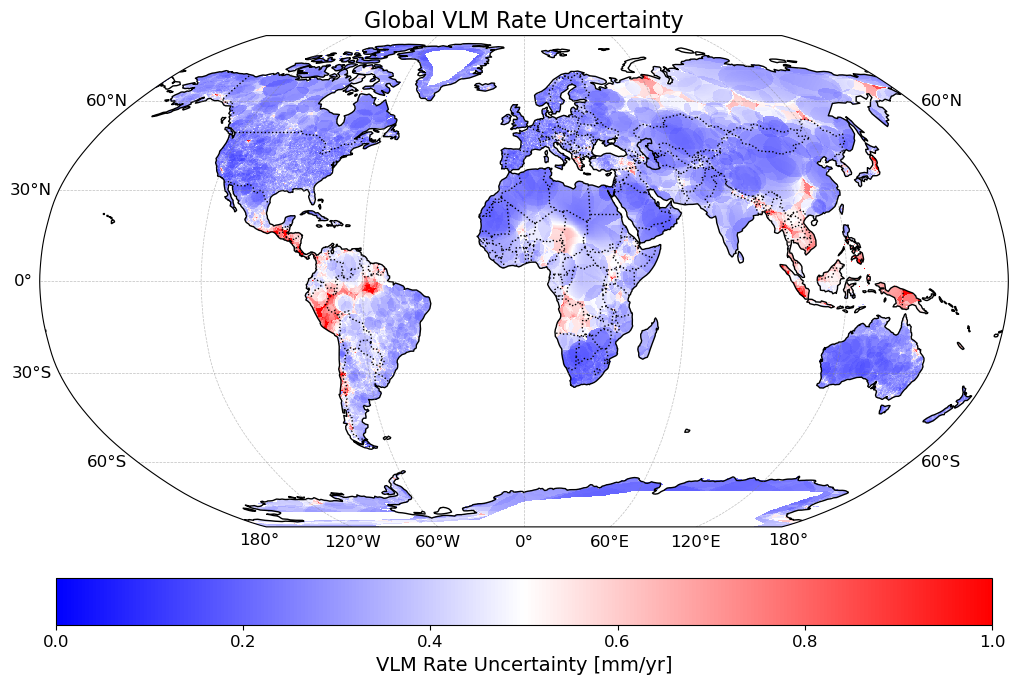

In [22]:
fig, ax = plt.subplots(figsize=(12, 7), subplot_kw={'projection': ccrs.Robinson()})

# pcolormesh expects X, Y, Z all the same shape, use edge coordinates if possible
im = ax.pcolormesh(lon_grid, lat_grid, svu, cmap='bwr', shading='auto', transform=ccrs.PlateCarree(), vmin=0, vmax=1)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}

cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.08, shrink=0.8)
cbar.set_label('VLM Rate Uncertainty [mm/yr]', fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.title('Global VLM Rate Uncertainty', fontsize=16)
plt.tight_layout()
plt.show()

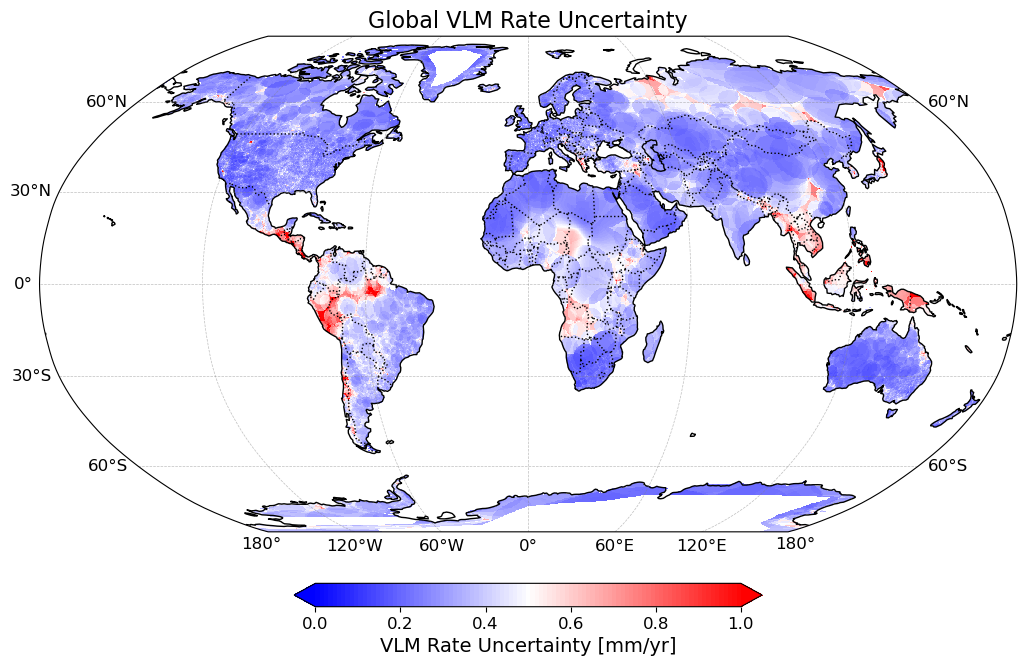

In [28]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
import matplotlib.ticker as ticker

# Load dataset
uncertainty = xr.open_dataset(r'VLM_Global_Imaged.nc')

# Extract 2D grid and SVU data
lon_grid = uncertainty['LonGrid'].values
lat_grid = uncertainty['LatGrid'].values
svu = uncertainty['SVU'].values

# Transpose if necessary so shape matches (Lat, Lon)
if svu.shape != (lat_grid.shape[1], lon_grid.shape[0]):
    lon_grid = lon_grid.T
    lat_grid = lat_grid.T
    svu = svu.T

# Define discrete color intervals for the colorbar
color_levels = np.linspace(0, 1, 100)  # 10 discrete intervals: 0.0, 0.1, ..., 1.0
cmap = plt.get_cmap('bwr')
norm = BoundaryNorm(color_levels, ncolors=cmap.N, extend='both')

fig, ax = plt.subplots(figsize=(12, 7), subplot_kw={'projection': ccrs.Robinson()})

# Use norm and cmap for discrete colors
im = ax.pcolormesh(
    lon_grid, lat_grid, svu,
    cmap=cmap, norm=norm,
    shading='auto', transform=ccrs.PlateCarree()
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}

major_ticks = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

# Add colorbar with discrete levels on major ticks
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.08, shrink=0.4, extend='both')
cbar.set_label('VLM Rate Uncertainty [mm/yr]', fontsize=14)

# cbar.set_ticks(color_levels)  # set color levels as major ticks

cbar.set_ticks(major_ticks)
cbar.minorticks_off()
cbar.ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
cbar.ax.tick_params(labelsize=12)

# plt.title('Global VLM Rate Uncertainty', fontsize=16)
plt.tight_layout()
plt.show()

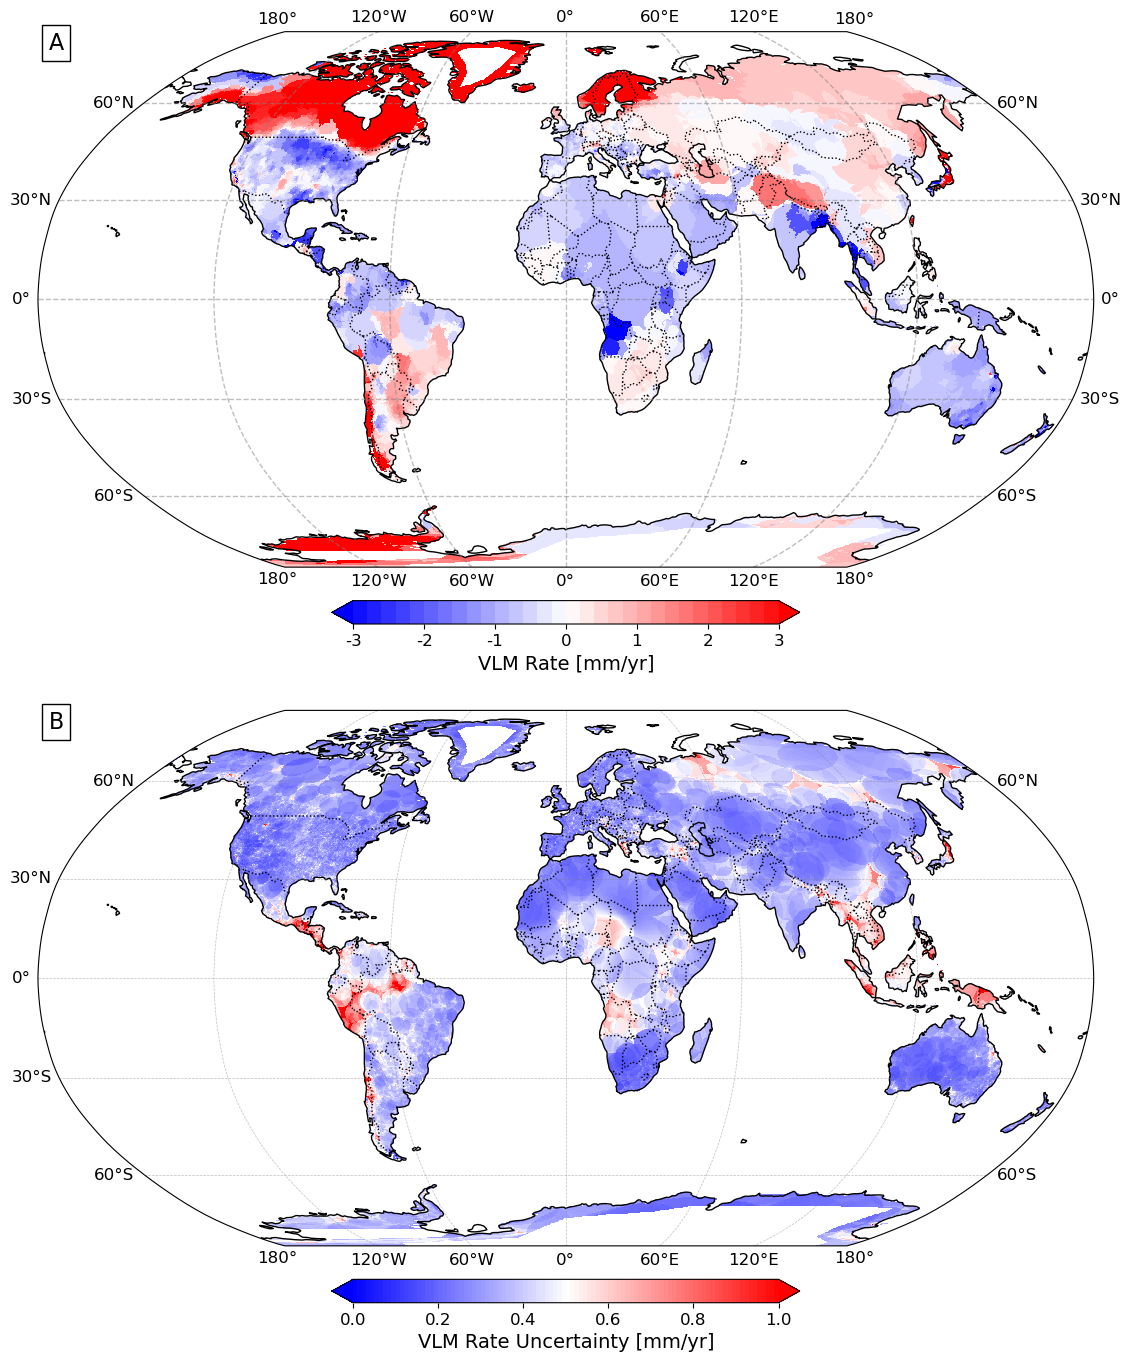

In [33]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
import matplotlib.ticker as ticker
import numpy as np
import xarray as xr

# Load your data (replace with your actual loading code)
VLM_Rate = xr.open_dataset(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Processed Data/VLM_Rate.nc')
vlm = VLM_Rate['VLM_Rate']
lon = VLM_Rate['lon'].values  
lat = VLM_Rate['lat'].values  

uncertainty = xr.open_dataset(r'VLM_Global_Imaged.nc')
lon_grid = uncertainty['LonGrid'].values
lat_grid = uncertainty['LatGrid'].values
svu = uncertainty['SVU'].values

if svu.shape != (lat_grid.shape[1], lon_grid.shape[0]):
    lon_grid = lon_grid.T
    lat_grid = lat_grid.T
    svu = svu.T

# Create figure and 2x1 subplots with Cartopy projections
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 14),
                         subplot_kw={'projection': ccrs.Robinson()})

# First subplot (VLM Rate)
ax1 = axes[0]
x2d, y2d = np.meshgrid(lon, lat)
color_levels_vlm = np.linspace(-3, 3, 31)
cmap_vlm = plt.get_cmap('bwr')
norm_vlm = BoundaryNorm(color_levels_vlm, ncolors=cmap_vlm.N, extend='both')

im1 = ax1.pcolormesh(x2d, y2d, vlm.values, cmap=cmap_vlm, norm=norm_vlm,
                     shading='auto', transform=ccrs.PlateCarree())

ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':')
gl1 = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl1.top_labels = True
gl1.xlabel_style = {'size': 12}
gl1.ylabel_style = {'size': 12}

cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.4, extend='both')
major_ticks_vlm = np.arange(-3, 4, 1)
cbar1.set_ticks(major_ticks_vlm)
cbar1.minorticks_off()
cbar1.ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
cbar1.set_label('VLM Rate [mm/yr]', fontsize=14)
cbar1.ax.tick_params(labelsize=12)

# Second subplot (Uncertainty)
ax2 = axes[1]
color_levels_uncertainty = np.linspace(0, 1, 101)
cmap_uncertainty = plt.get_cmap('bwr')
norm_uncertainty = BoundaryNorm(color_levels_uncertainty, ncolors=cmap_uncertainty.N, extend='both')

im2 = ax2.pcolormesh(lon_grid, lat_grid, svu, cmap=cmap_uncertainty, norm=norm_uncertainty,
                     shading='auto', transform=ccrs.PlateCarree())

ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':')
gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl2.top_labels = False
gl2.right_labels = False
gl2.xlabel_style = {'size': 12}
gl2.ylabel_style = {'size': 12}

major_ticks_uncertainty = [0, 0.25, 0.50, 0.75, 1.0]
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.4, extend='both')
cbar2.set_ticks(major_ticks_uncertainty)
cbar2.minorticks_off()
cbar2.ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
cbar2.set_label('VLM Rate Uncertainty [mm/yr]', fontsize=14)
cbar2.ax.tick_params(labelsize=12)

# For upper subplot (ax1)
ax1.text(0.01, 1.0, 'A', transform=ax1.transAxes,
         fontsize=16, fontweight='normal', va='top', ha='left',
         bbox=dict(boxstyle='square,pad=0.3', fc='white', ec='black', lw=1))

# For lower subplot (ax2)
ax2.text(0.01, 1.0, 'B', transform=ax2.transAxes,
         fontsize=16, fontweight='normal', va='top', ha='left',
         bbox=dict(boxstyle='square,pad=0.3', fc='white', ec='black', lw=1))


plt.tight_layout()
plt.show()

C:\Users\sudur\AppData\Local\Temp\ipykernel_2544\3978847329.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


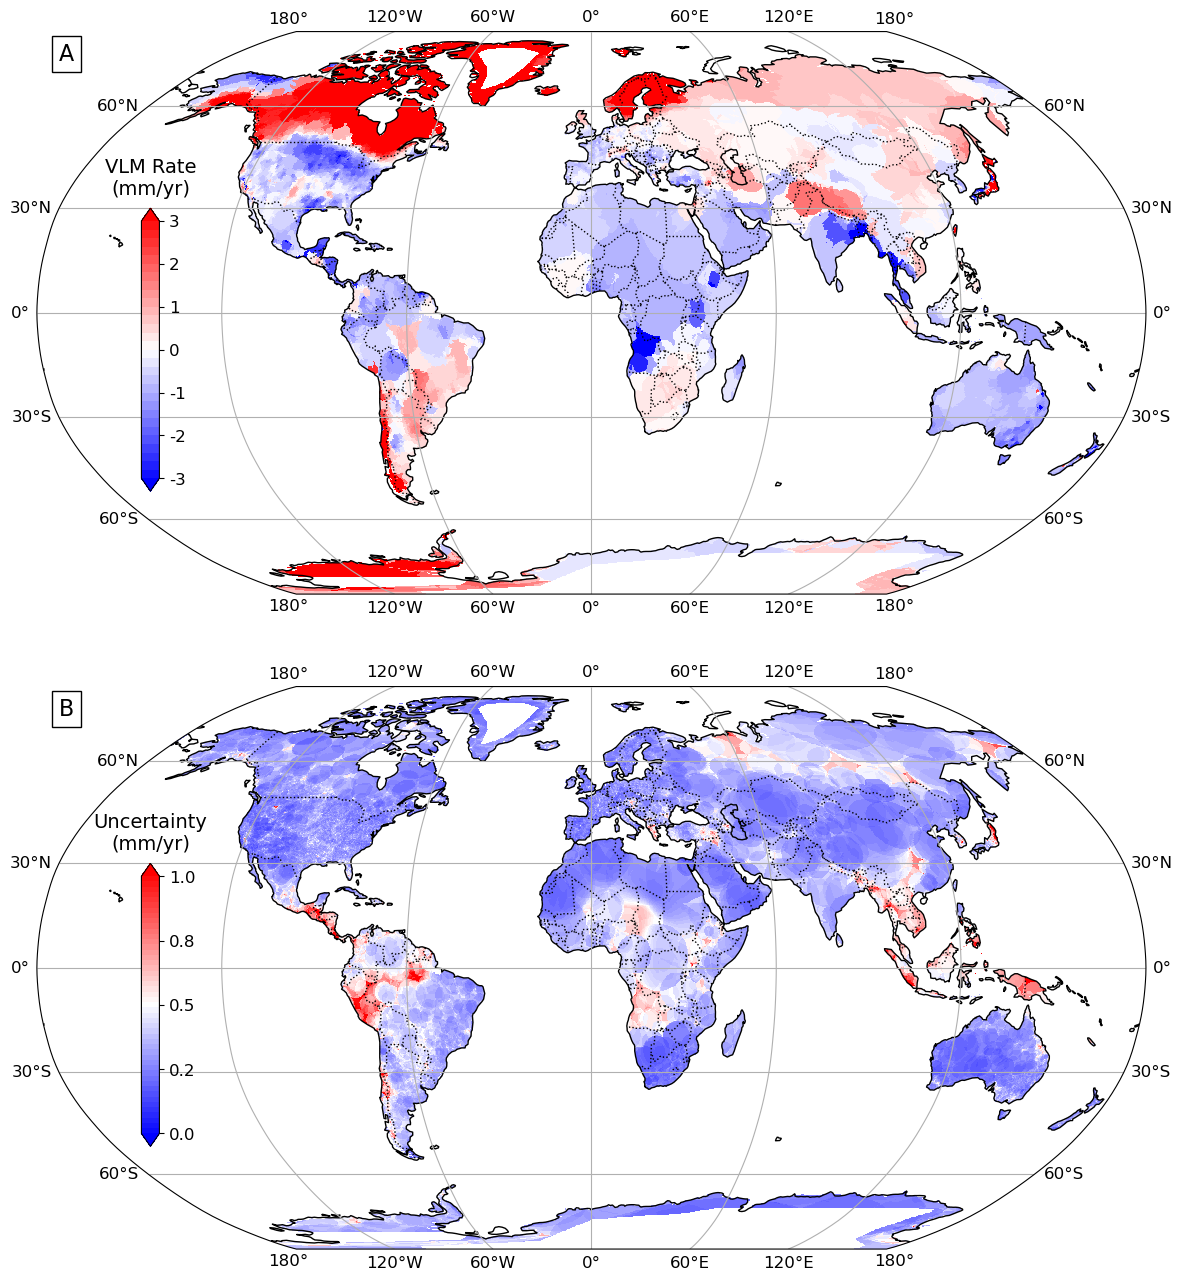

In [98]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
import matplotlib.ticker as ticker

# Load datasets
VLM_Rate = xr.open_dataset('D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Processed Data/VLM_Rate.nc')
vlm = VLM_Rate['VLM_Rate']
lon = VLM_Rate['lon'].values
lat = VLM_Rate['lat'].values

uncertainty = xr.open_dataset('VLM_Global_Imaged.nc')
lon_grid = uncertainty['LonGrid'].values
lat_grid = uncertainty['LatGrid'].values
svu = uncertainty['SVU'].values
if svu.shape != (lat_grid.shape[1], lon_grid.shape[0]):
    lon_grid = lon_grid.T
    lat_grid = lat_grid.T
    svu = svu.T

# Create figure with 2 subplots (2 rows, 1 column), both with cartopy projection
fig, axes = plt.subplots(2, 1, figsize=(12, 14),
                         subplot_kw={'projection': ccrs.Robinson()})

# ------------------ Plot 1: VLM Rate ----------------------
ax1 = axes[0]
x2d, y2d = np.meshgrid(lon, lat)
color_levels_vlm = np.linspace(-3, 3, 31)
cmap_vlm = plt.get_cmap('bwr')
norm_vlm = BoundaryNorm(color_levels_vlm, ncolors=cmap_vlm.N, extend='both')

im1 = ax1.pcolormesh(x2d, y2d, vlm.values, cmap=cmap_vlm, norm=norm_vlm,
                       shading='auto', transform=ccrs.PlateCarree())

ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':')
# ax1.set_title('VLM Rate Map')
gl1 = ax1.gridlines(draw_labels=True)
gl1.top_labels = True
gl1.xlabel_style = {'size': 12}
gl1.ylabel_style = {'size': 12}

# Add annotation box "A" in upper left
ax1.text(0.02, 0.98, 'A', transform=ax1.transAxes,
         fontsize=16, fontweight='normal', va='top', ha='left',
         bbox=dict(boxstyle='square,pad=0.3', fc='white', ec='black', lw=1))

# Horizontal, placed within the first plot
# Custom colorbar axes for vertical placement at relative x=0.2 & x=0.3
pos1 = ax1.get_position()

cax1 = fig.add_axes([pos1.x0, pos1.y0 + 0.07, 0.015, pos1.height*0.6])
cbar1 = fig.colorbar(im1, cax=cax1, orientation='vertical')
cbar1.set_ticks(np.arange(-3, 4, 1))
cbar1.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
cbar1.minorticks_off()
# cbar1.ax.set_label('[mm/yr]', fontsize=16, labelpad=10, loc='top')
cbar1.ax.set_title('VLM Rate\n(mm/yr)', fontsize=14, pad=10)

cbar1.ax.tick_params(labelsize=12)

# ------------------ Plot 2: Uncertainty ----------------------
ax2 = axes[1]
color_levels_uncertainty = np.linspace(0, 1, 50)
cmap_uncertainty = plt.get_cmap('bwr')
norm_uncertainty = BoundaryNorm(color_levels_uncertainty, ncolors=cmap_uncertainty.N, extend='both')

im2 = ax2.pcolormesh(lon_grid, lat_grid, svu, cmap=cmap_uncertainty, norm=norm_uncertainty,
                       shading='auto', transform=ccrs.PlateCarree())

ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':')
# ax2.set_title('VLM Uncertainty Map')
gl2 = ax2.gridlines(draw_labels=True)
gl2.top_labels = True
gl2.right_labels = True
gl2.xlabel_style = {'size': 12}
gl2.ylabel_style = {'size': 12}

# Add annotation box "B" in upper left
ax2.text(0.02, 0.98, 'B', transform=ax2.transAxes,
         fontsize=16, fontweight='normal', va='top', ha='left',
         bbox=dict(boxstyle='square,pad=0.3', fc='white', ec='black', lw=1))

# Custom colorbar axes for vertical placement at relative x=0.3
pos2 = ax2.get_position()
cax2 = fig.add_axes([pos2.x0, pos2.y0 + 0.022, 0.015, pos2.height*0.6])
cbar2 = fig.colorbar(im2, cax=cax2, orientation='vertical')
cbar2.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar2.minorticks_off()
cbar2.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
cbar2.ax.set_title('Uncertainty\n(mm/yr)', fontsize=14, pad=10)
cbar2.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.subplots_adjust(hspace=-0.05)
plt.savefig(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Processed Data/Global_VLM_Rate_and_Uncertianty.png', dpi=300, bbox_inches='tight')
plt.show()